<a href="https://colab.research.google.com/github/asesofspade/LUAU-Animations-PRELOADER/blob/main/MATH_SOLVER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytesseract pillow
!pip install transformers torch
!apt-get update
!apt-get install -y tesseract-ocr tesseract-ocr-spa

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-spa is already th

INPUT


In [ ]:
import os
from google.colab import files
from PIL import Image, ImageFilter, ImageEnhance
import pytesseract

def _upload_image():
    uploaded = files.upload()
    return list(uploaded.keys())[0]

def get_image():
    extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp')
    existing_images = []

    for root, dirs, files_found in os.walk('.'):
        for file in files_found:
            if file.lower().endswith(extensions):
                existing_images.append(os.path.join(root, file))

    if existing_images:
        for i, path in enumerate(existing_images, 1):
            print(f"[{i}] {path}")
        print("[0] Upload new image")
        option = input("Option: ").strip()

        if option == '0':
            return _upload_image()
        elif option.isdigit() and 1 <= int(option) <= len(existing_images):
            return existing_images[int(option) - 1]
        else:
            return _upload_image()
    else:
        return _upload_image()

image_path = get_image()

[1] ./input_samples/SAMPLE5.jpeg
[2] ./input_samples/SAMPLE4.jpeg
[3] ./input_samples/SAMPLE2.png
[4] ./input_samples/SAMPLE1.png
[5] ./input_samples/SAMPLE3.jpg
[0] Upload new image
Option: 1


Preprocessing

In [ ]:
import numpy as np
from PIL import ImageOps

def preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((img.width * 5, img.height * 3), Image.LANCZOS)
    img = ImageEnhance.Contrast(img).enhance(3.0)
    img = ImageEnhance.Sharpness(img).enhance(4.0)
    img = img.convert('L')
    img = ImageEnhance.Brightness(img).enhance(2.5)
    return img

processed = preprocess_image(image_path)
display(processed)

OCR

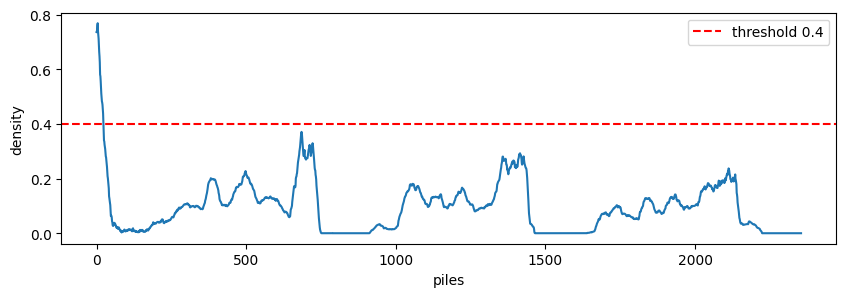

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.array(processed.convert('L'))
mask = arr < 200
row_density = mask.sum(axis=1) / mask.shape[1]

plt.figure(figsize=(10, 3))
plt.plot(row_density)
plt.axhline(y=0.4, color='r', linestyle='--', label='threshold 0.4')
plt.xlabel('piles')
plt.ylabel('density')
plt.legend()
plt.show()

In [ ]:
import numpy as np

import numpy as np

def split_lines(img):
    arr = np.array(img.convert('L'))
    mask = arr < 200
    row_density = mask.sum(axis=1) / mask.shape[1]

    valleys = np.where(row_density < 0.02)[0]

    split_points = [0]
    for i in range(1, len(valleys)):
        if valleys[i] - valleys[i-1] > 50:
            split_points.append(valleys[i])
    split_points.append(img.height)

    lines = []
    for i in range(len(split_points) - 1):
        top = split_points[i]
        bottom = split_points[i+1]
        crop = img.crop((0, top, img.width, bottom))
        arr_crop = np.array(crop.convert('L'))
        if (arr_crop < 200).sum() > 500:
            lines.append(crop)

    return lines

line_images = split_lines(processed)
for i, line in enumerate(line_images, 1):
    display(line)

In [ ]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-large-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-large-handwritten')

lines_output = []
for line_img in line_images:
    arr = np.array(line_img.convert('L'))
    if (arr < 200).sum() < 1000:
        continue
    pixel_values = processor(line_img.convert('RGB'), return_tensors='pt').pixel_values
    generated_ids = model.generate(pixel_values)
    output = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print(f'crudo: {output}')
    lines_output.append(output)

Loading weights:   0%|          | 0/635 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-large-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


crudo: 1/2x # 6-2/
crudo: 2i 3x - 8f30 .
crudo: 3.5x - 9 #0 .
crudo: 1961 62m.


In [ ]:
import re

def fix_math(text):
    text = text.replace('"', ':')
    text = re.sub(r'^(\d)/', r'\1:', text)
    text = re.sub(r'(\d)i ', r'\1: ', text)
    text = re.sub(r'^(\d)\.(\d)', r'\1:\2', text)
    text = re.sub(r'f(\d)', r'=\1', text)
    text = re.sub(r'-(\d)7$', r'=\g<1>7', text)
    text = re.sub(r'(\d)/', r'\g<1>7', text)
    text = re.sub(r'(\d+[a-z]?)\s*#\s*(\d)', r'\1+\2', text)
    text = re.sub(r'([a-z\d])\s*#\s*(\d)', r'\1=\2', text)
    text = re.sub(r'-\s*#\s*(\d)', r'=-\1', text)
    text = re.sub(r'\+0', r'=0', text)
    text = re.sub(r'\s*([+\-=:])\s*', r'\1', text)
    text = re.sub(r'-(?=\d+$)', r'=', text)
    return re.sub(r'[\s.]+', '', text)

for i, line in enumerate(lines_output, 1):
    cleaned = fix_math(line)
    if len(cleaned) > 3 and not re.match(r'^\d+[a-z]?\d*$', cleaned) and 'Navigation' not in cleaned:
        print(f'Linea {i}: {cleaned}')


Linea 1: 1:2x+6=27
Linea 2: 2:3x-8=30
Linea 3: 3:5x-9=0


In [ ]:
from sympy import symbols, Eq, solve, sympify
import re

x = symbols('x')

for i, line in enumerate(lines_output, 1):
    cleaned = fix_math(line)
    if len(cleaned) > 3 and not re.match(r'^\d+[a-z]?\d*$', cleaned) and 'Navigation' not in cleaned:
        try:
            ecuacion_str = cleaned.split(':', 1)[-1]
            ecuacion_str = re.sub(r'(\d)([a-z])', r'\1*\2', ecuacion_str)
            izq, der = ecuacion_str.rsplit('=', 1)
            eq = Eq(sympify(izq), sympify(der))
            sol = solve(eq, x)
            print(f'Solucion {i}: x = {sol}')
        except Exception as e:
            print(f'Solucion {i}: Error - {e}')

Solucion 1: x = [21/2]
Solucion 2: x = [38/3]
Solucion 3: x = [9/5]
